In [1]:
!pip install numpy pandas matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")

In [3]:
import os

for dirname, _, filenames in os.walk(r"C:\Users\Acer\Downloads\GiveMeSomeCreditData"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


C:\Users\Acer\Downloads\GiveMeSomeCreditData\cs-test.csv
C:\Users\Acer\Downloads\GiveMeSomeCreditData\cs-training.csv
C:\Users\Acer\Downloads\GiveMeSomeCreditData\Data Dictionary.xls
C:\Users\Acer\Downloads\GiveMeSomeCreditData\sampleEntry.csv


In [4]:
!pip install numpy pandas scikit-learn xgboost matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split

# Modelling & Feature Selection
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline

# Evaluation & Metrics
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")

In [7]:
!pip install xlrd


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
train = pd.read_csv(r"C:\Users\Acer\Downloads\GiveMeSomeCreditData\cs-training.csv")
test = pd.read_csv(r"C:\Users\Acer\Downloads\GiveMeSomeCreditData\cs-test.csv")
data_excel = pd.read_excel(r"C:\Users\Acer\Downloads\GiveMeSomeCreditData\Data Dictionary.xls")
sample_data = pd.read_csv(r"C:\Users\Acer\Downloads\GiveMeSomeCreditData\sampleEntry.csv")

In [9]:
train_df = train.copy()
test_df = test.copy()

For Basic EDA we will check following to learn basic insights.

Data Structure - Checking Data Types, Column Names and Shape of Data.
Missing values - Identifying columns with missing values.
Data Summary - Get basic summary of overall data.
Feature Distribution - Using histogram, boxplot to inspect feature spread.
Correlation - Examine correlation of each variable with target.
Categorical Insight - Use boxplot, etc to spot outliers.
Trend by Target - Compare Distributions across target values.

DATA STRUCTURE AND MISSING VALUES

In [10]:
print("====== SUMMARY =======")
print()
print(f"Training set size: {train_df.shape}")
print(f"Testing set size:  {test_df.shape}")
print()
print(f"All features in the training dataset: {', '.join(map(str, train_df.columns))}")
print(f"All features in the testing dataset: {', '.join(map(str, test_df.columns))}")
print()
print("---Training set survivability---")
print(f"Number of Applicants: {train_df.shape[0]}")
print(f"Number of Applicants with financial distress = {len(train_df[train_df['SeriousDlqin2yrs'] == 1])}")
print(f"Percentage of Applicants with financial distress = {len(train_df[train_df['SeriousDlqin2yrs'] == 1]) / train_df.shape[0] * 100} %")
print()
print("---Missing data [%]---")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print()
print("---Data types---")
print(train_df.info())
print()

====== SUMMARY =======

Training set size: (150000, 12)
Testing set size:  (101503, 12)

All features in the training dataset: Unnamed: 0, SeriousDlqin2yrs, RevolvingUtilizationOfUnsecuredLines, age, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents
All features in the testing dataset: Unnamed: 0, SeriousDlqin2yrs, RevolvingUtilizationOfUnsecuredLines, age, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents

---Training set survivability---
Number of Applicants: 150000
Number of Applicants with financial distress = 10026
Percentage of Applicants with financial distress = 6.683999999999999 %

---Missing data [%]---
MonthlyIncome         29731
NumberOfDependents     3924
dtype

DATA SUMMARY

In [11]:
print("---Statistical summary---")
round(train_df.describe(),2)

---Statistical summary---


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


FEATURE DISTRIBUTION

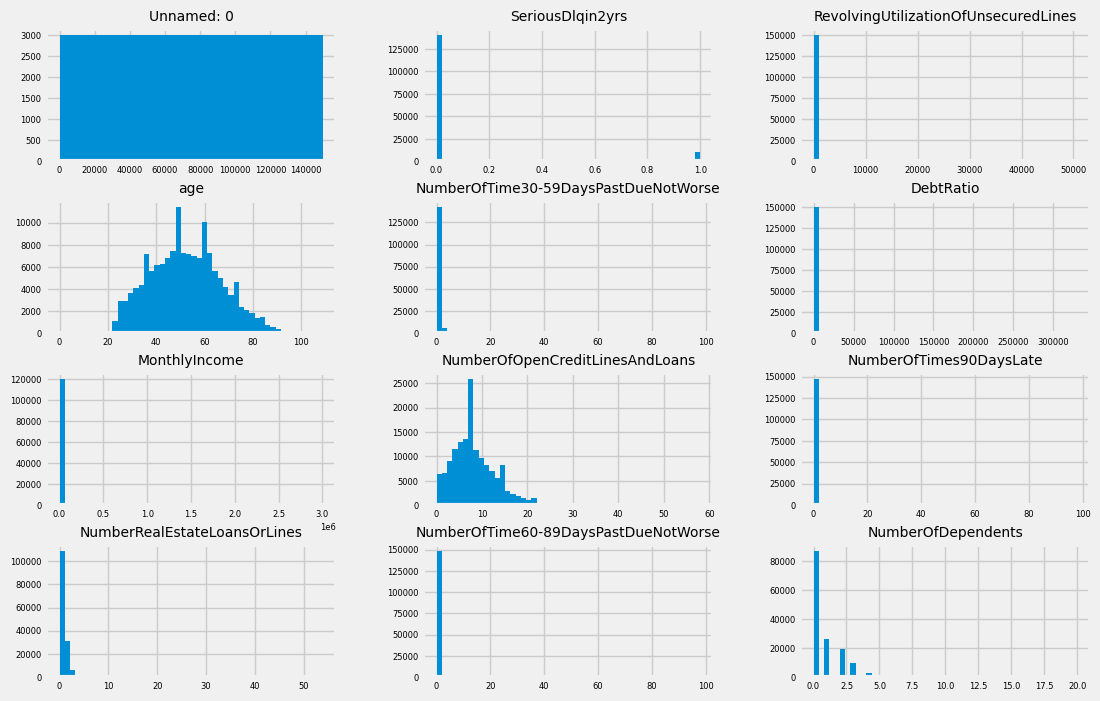

In [12]:
plt.rc('font',size=10)
plt.rc('axes',labelsize=10,titlesize=10)
plt.rc('legend',fontsize=8)
plt.rc('xtick',labelsize=6)
plt.rc('ytick',labelsize=6)

train_df.hist(bins=50,figsize=(12,8))
plt.show()

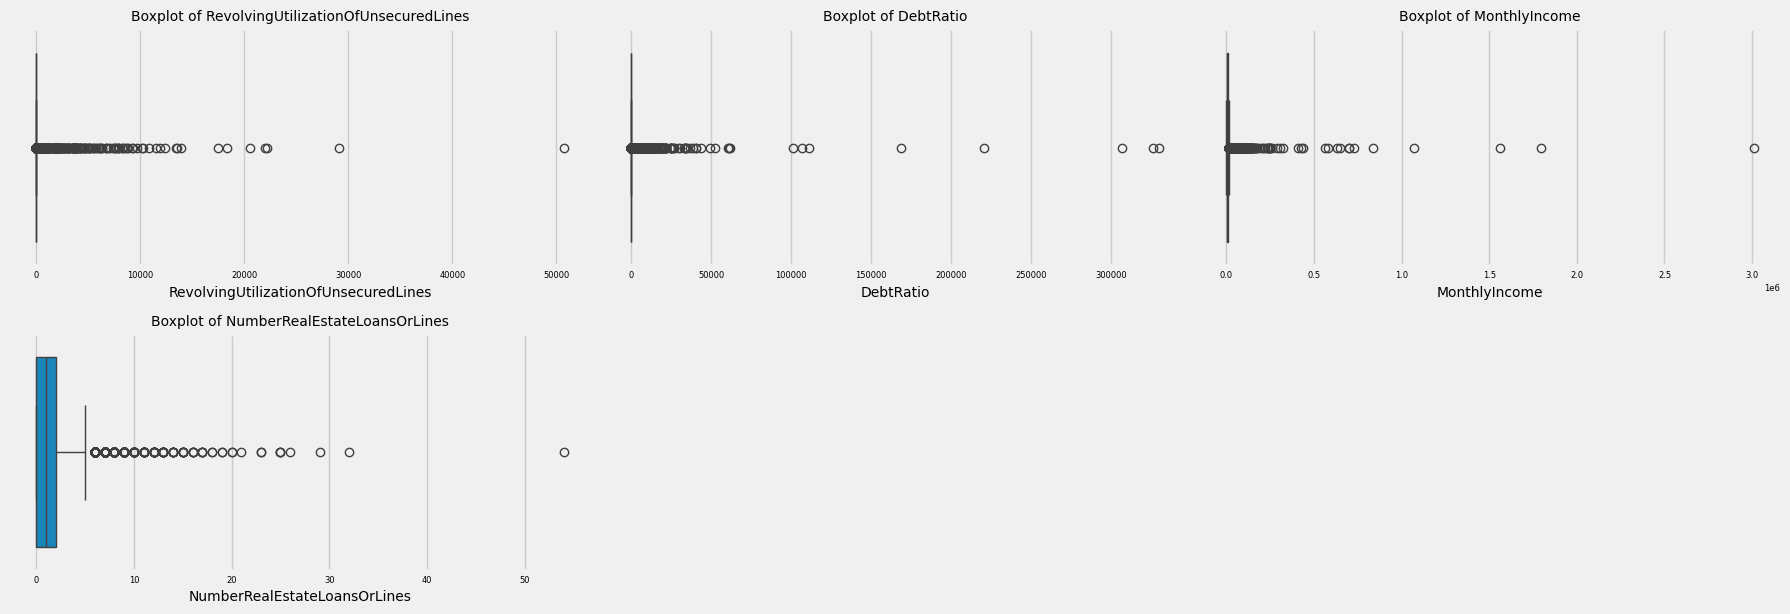

In [13]:
outliers_col = ['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome','NumberRealEstateLoansOrLines']
plt.figure(figsize=(18, 12)) # Set overall figure size
for i, col in enumerate(train_df[outliers_col], 1):
    plt.subplot(4, 3, i) # Create subplot in 4x3 grid
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

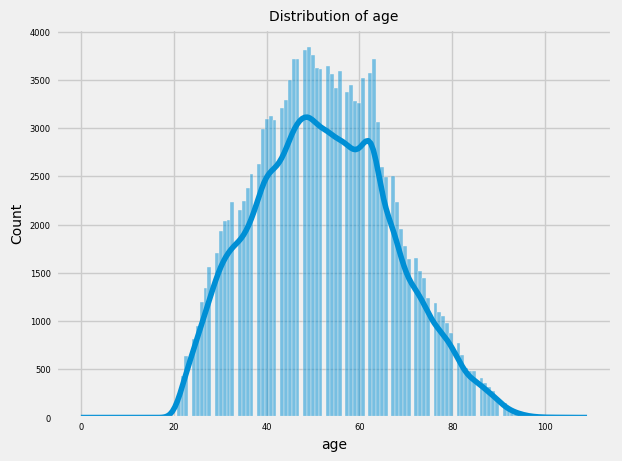

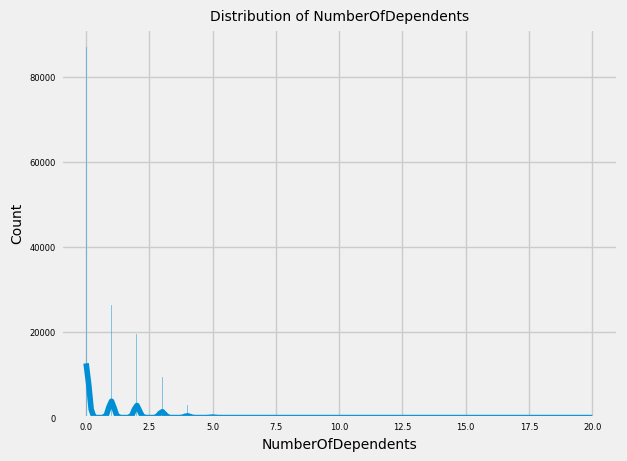

In [14]:
dist_col = ['age','NumberOfDependents']

for col in train_df[dist_col]:
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

NumberOfOpenCreditLinesAndLoans is skewed. Need to take log to get rid of skewness.

CORRELATION BETWEEN VARIABLES AND WITH TARGET VARIABLE

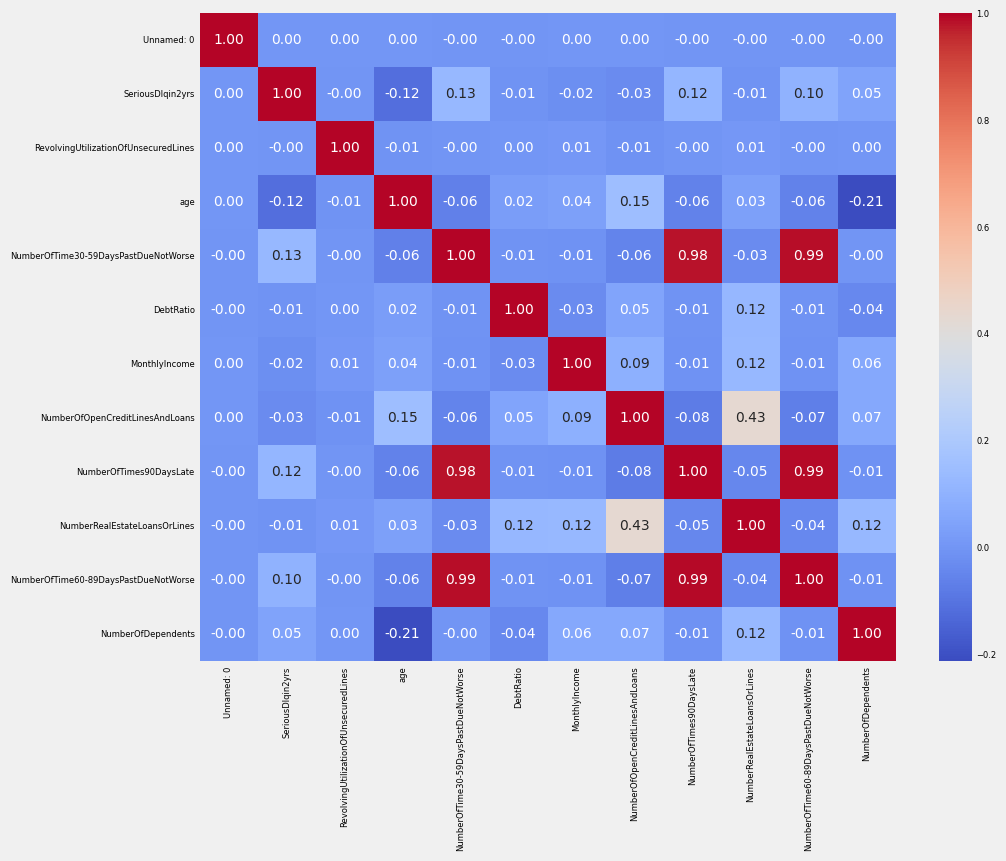

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

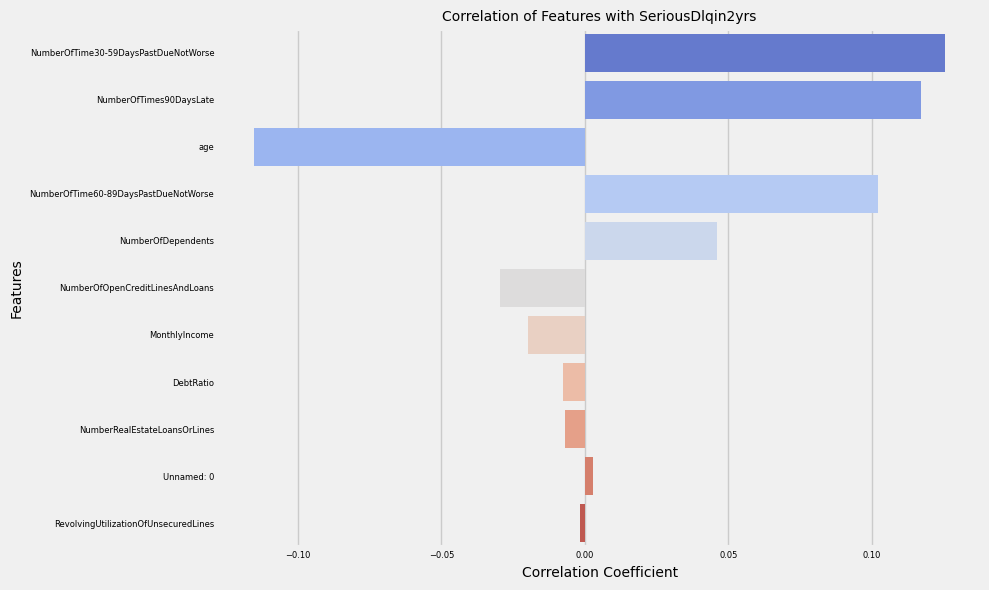

In [16]:
# Calculate correlation of each feature with SeriousDlqin2yrs
target_corr = train_df.corr()['SeriousDlqin2yrs']

# Sort correlations by absolute value (optional, for better visualization)
target_corr = target_corr.sort_values(key=abs, ascending=False).drop('SeriousDlqin2yrs')

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")
plt.title("Correlation of Features with SeriousDlqin2yrs")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

FEATURE ENGINEERING AND HANDLING MISSING DATA

1. Age group is derived from age column.
2. Missing value of Income is imputed basis on median values of particular age group.
3. IQR method is used to handle the outliers in RevolvingUtilizationOfUnsecuredLines, DebtRatio, MonthlyIncome, NumberRealEstateLoansOrLines. These col have few 0 values hence IQR seems appropriate.
4. The cols NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate are converted into binary categories (0 for No and 1 for Yes) as this would provide more meaning than absolute values.
5. As NumberOfOpenCreditLinesAndLoans is skewed to right, hence log1p is used.

In [17]:
def preprocess(df):

    df = df.copy()

    # Creating Age Groups and filling missing values of Monthly Income based on age group
    bins = [0,25,35,45,55,70,float('inf')]
    labels = [0,1,2,3,4,5]
    df['age_group'] = pd.cut(df['age'],bins=bins,labels=labels,include_lowest=True)

    median_income_by_age = df.groupby('age_group')['MonthlyIncome'].median()

    df['MonthlyIncome'] = df['MonthlyIncome'].replace(0, np.nan)
    df['MonthlyIncome'] = df.apply(lambda row:  median_income_by_age[row['age_group']] if pd.isnull(row['MonthlyIncome'])
                                          else row['MonthlyIncome'],axis=1)
    print("Remaining missing values in MonthlyIncome:", df['MonthlyIncome'].isnull().sum())
    # Handling outliers using IQR method 

    outliers_col = ['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome','NumberRealEstateLoansOrLines']

    for col in outliers_col:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    # Converting num columns into categories

    df['30-59_Due'] = df['NumberOfTime30-59DaysPastDueNotWorse'].apply(lambda x: 0 if x == 0 else 1 if x < 5 else 2)
    df['60-89_Due'] = df['NumberOfTime60-89DaysPastDueNotWorse'].apply(lambda x: 0 if x == 0 else 1 if x < 5 else 2)
    df['90+_Due'] = df['NumberOfTimes90DaysLate'].apply(lambda x: 0 if x == 0 else 1 if x < 5 else 2)

    df['NumberOfDependents'] = df['NumberOfDependents'].apply(lambda x: 0 if x == 0 else 1)
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(value=df['NumberOfDependents'].mode()[0])

    df['NumberOfOpenCreditLinesAndLoans'] = np.log1p(df['NumberOfOpenCreditLinesAndLoans'])
    
    df = df.drop(['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate','age'],axis=1)

    return df

In [18]:
preprocessed_train_df = preprocess(train_df)
preprocessed_test_df = preprocess(test_df)
preprocessed_train_df.info()

Remaining missing values in MonthlyIncome: 0
Remaining missing values in MonthlyIncome: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   Unnamed: 0                            150000 non-null  int64   
 1   SeriousDlqin2yrs                      150000 non-null  int64   
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64 
 3   DebtRatio                             150000 non-null  float64 
 4   MonthlyIncome                         150000 non-null  float64 
 5   NumberOfOpenCreditLinesAndLoans       150000 non-null  float64 
 6   NumberRealEstateLoansOrLines          150000 non-null  int64   
 7   NumberOfDependents                    150000 non-null  int64   
 8   age_group                             150000 non-null  category
 9   30-59_Due                          

MODEL EVALUATION

We will split the data into train and validation to test our model. We will create a pipeline that will do column transformations (Scaling Num cols and Encoding Cat cols) and then apply the model. Here we have imbalanced target class (6.6% as delinquent). To establish a baseline model, we will run Logistic Regression without balancing target class and have basic Precision, Recall and F1 score. Once we establish it, we will run same regression with balanced class weight.

In [19]:
cat = ['NumberRealEstateLoansOrLines','NumberOfDependents','age_group','30-59_Due','60-89_Due','90+_Due']
num = ['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome','NumberOfOpenCreditLinesAndLoans']

In [20]:
y = preprocessed_train_df['SeriousDlqin2yrs']
X = preprocessed_train_df.drop(['SeriousDlqin2yrs'],axis=1)

In [21]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=45)

In [22]:
cat_encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
scaler = StandardScaler()
logit = LogisticRegression(random_state=45)
col_transformer = make_column_transformer((cat_encoder,cat),(scaler,num),remainder='passthrough')

pipeline_basic = Pipeline([('col',col_transformer),('clf',logit)])

In [23]:
model = pipeline_basic.fit(X_train,y_train)

In [24]:
predict_val = model.predict(X_val)

In [25]:
precision_logit_unbalance = precision_score(y_val,predict_val)
print(f"Precision : {precision_logit_unbalance:.04f}")

recall_logit_unbalance = recall_score(y_val,predict_val)
print(f"Recall : {recall_logit_unbalance:.04f}")

f1_logit_unbalance = f1_score(y_val,predict_val)
print(f"F1 : {f1_logit_unbalance:.4f}")

Precision : 0.5392
Recall : 0.1659
F1 : 0.2537


In [26]:
np.unique(predict_val, return_counts=True)

(array([0, 1]), array([29388,   612]))

In [27]:
logit_bal = LogisticRegression(class_weight='balanced', random_state=45)
pipeline_logit = Pipeline([('col',col_transformer),('clf',logit_bal)])
model_logit_bal = pipeline_logit.fit(X_train,y_train)

In [28]:
pred_val_logit = model_logit_bal.predict(X_val)

In [29]:
precision_logit = precision_score(y_val,pred_val_logit)
print(f"Precision : {precision_logit:.4f}")

recall_logit = recall_score(y_val,pred_val_logit)
print(f"Recall : {recall_logit:.4f}")

f1_logit = f1_score(y_val,pred_val_logit)
print(f"F1 : {f1_logit:.4f}")

Precision : 0.2077
Recall : 0.7416
F1 : 0.3245


We will move ahead and train Random Forest and XGBoost as well. Both these models handle Non-linearity, Outliers and class imbalances better than Logistic Regression.

In [30]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(class_weight = 'balanced',n_estimators=200,max_depth=6,min_samples_leaf=2,random_state=45)
pipeline_rf = Pipeline([('col',col_transformer),('clf',rfc)])

In [31]:
RFC_model = pipeline_rf.fit(X_train,y_train)

In [32]:
pred_val_rfc = RFC_model.predict(X_val)

In [33]:
precision_rfc = precision_score(y_val,pred_val_rfc)
print(f"Precision : {precision_rfc:.4f}")

recall_rfc = recall_score(y_val,pred_val_rfc)
print(f"Recall : {recall_rfc:.4f}")

f1_rfc = f1_score(y_val,pred_val_rfc)
print(f"F1 : {f1_rfc:.4f}")

Precision : 0.2202
Recall : 0.7225
F1 : 0.3376


By default the Threshold is 0.5 for classification. We will try different thresholds to check the impact on evaluation parameters.

In [35]:
y_prob = RFC_model.predict_proba(X_val)[:, 1]

# Threshold = 0.3
custom_thresh = 0.3
y_pred_thresh = (y_prob >= custom_thresh).astype(int)

P03 = round(precision_score(y_val, y_pred_thresh), 4)
R03 = round(recall_score(y_val, y_pred_thresh), 4)
F03 = round(f1_score(y_val, y_pred_thresh), 4)

print(f"Precision: {P03}")
print(f"Recall: {R03}")
print(f"F1: {F03}")

Precision: 0.1424
Recall: 0.8889
F1: 0.2454


In [37]:
y_prob = RFC_model.predict_proba(X_val)[:, 1]

# Threshold = 0.4
custom_thresh = 0.4
y_pred_thresh = (y_prob >= custom_thresh).astype(int)

P04 = round(precision_score(y_val, y_pred_thresh), 4)
R04 = round(recall_score(y_val, y_pred_thresh), 4)
F04 = round(f1_score(y_val, y_pred_thresh), 4)

print(f"Precision: {P04}")
print(f"Recall: {R04}")
print(f"F1: {F04}")

Precision: 0.157
Recall: 0.8592
F1: 0.2655


In [39]:
y_prob = RFC_model.predict_proba(X_val)[:, 1]

# Threshold = 0.7
custom_thresh = 0.7
y_pred_thresh = (y_prob >= custom_thresh).astype(int)

P07 = round(precision_score(y_val, y_pred_thresh), 4)
R07 = round(recall_score(y_val, y_pred_thresh), 4)
F07 = round(f1_score(y_val, y_pred_thresh), 4)

print(f"Precision: {P07}")
print(f"Recall: {R07}")
print(f"F1: {F07}")

Precision: 0.3632
Recall: 0.5153
F1: 0.4261


Depending on business need, the threshold can be adjusted. For example, a threshold of 0.3 gives recall of 88.9%, ideal for risk-flagging, while 0.5 balances all metrics well.
In typical lending scenarios, recall is prioritized to reduce risk. However, I’ve also evaluated threshold-tuned precision scores to allow for business-specific trade-offs, such as flagging high-risk customers for manual review vs. auto-rejection.

In [40]:
RFC_comparision = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Threshold 0.3': [
        P03,R03,F03],
    'Threshold 0.5': [
        precision_rfc,recall_rfc,f1_rfc],
    'Threshold 0.7': [
        P07,R07,F07],
    'Use Cases':[
        "For Flaging risking Profiles",
        "Balanced System",
        "Auto Rejecting High Risk Profiles"]
})

RFC_comparision = RFC_comparision.round(4)

RFC_comparision

,Metric,Threshold 0.3,Threshold 0.5,Threshold 0.7,Use Cases
0,Precision,0.1424,0.2202,0.3632,For Flaging risking Profiles
1,Recall,0.8889,0.7225,0.5153,Balanced System
2,F1 Score,0.2454,0.3376,0.4261,Auto Rejecting High Risk Profiles


In [41]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=45
)

In [42]:
pipeline_xgb = Pipeline([('col',col_transformer),('clf',xgb_model)])
model_xgb = pipeline_xgb.fit(X_train,y_train)

In [43]:
predict_val_xgb = model_xgb.predict(X_val)

In [45]:
precision_xgb = round(precision_score(y_val, predict_val_xgb),4)
recall_xgb = round(recall_score(y_val, predict_val_xgb),4)
f1_xgb = round(f1_score(y_val, predict_val_xgb),4)

print(f"Precision: {precision_xgb}")
print(f"Recall: {recall_xgb}")
print(f"F1: {f1_xgb}")

Precision: 0.2153
Recall: 0.7572
F1: 0.3353


In [46]:
Model_Comparision = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Logistic Regression (balanced)': [
        precision_logit,recall_logit,f1_logit],
    'Random Forest Classifier (balanced)': [
        precision_rfc,recall_rfc,f1_rfc],
    'XGBoost Classifier': [
        precision_xgb,recall_xgb,f1_xgb]
})

Model_Comparision = Model_Comparision.round(4)

Model_Comparision

,Metric,Logistic Regression (balanced),Random Forest Classifier (balanced),XGBoost Classifier
0,Precision,0.2077,0.2202,0.2153
1,Recall,0.7416,0.7225,0.7572
2,F1 Score,0.3245,0.3376,0.3353


We can clearly see that XGBoost Classifier gives us better recall than other models. It is 3% better than Random Forest and 5% better than Logisitic on the validation set.